# Credit Card Application Approval — K-Nearest Neighbors Classifier
### Domain: Banking Risk & Consumer Finance | Algorithm: K-Nearest Neighbors Classifier (`KNeighborsClassifier`)

---

## 📌 Complete 13-Step Enterprise Architecture (1-to-1 with `00_Common_ML_Workflow`)
1. **🌐 Step 1:** Universal Enterprise Libraries Import (from Guide 01)
2. **🌐 Step 2:** Robust Data Ingestion & 3-Sec Audit (from Guide 02)
3. **🧼 Step 2B:** Enterprise Data Sanitization & Cleaning (from Guide 02B)
4. **🌐 Step 3:** Automated 3-Bucket Feature Segregator (from Guide 03)
5. **🌐 Step 4:** Data Hygiene Audit (Duplicates & Missingness) (from Guide 04)
6. **🌐 Step 5:** Enterprise Train-Test Splitter (Zero Data Leakage + Target Guard) (from Guide 05)
7. **🌐 Step 6:** Target Analysis & Zero-Rule Baseline Trap Profiler (from Guide 06)
8. **🌐 Step 7:** Universal Master ColumnTransformer Preprocessor (from Guide 07)
9. **🧪 Step 8:** The Geometric Scaling Catastrophe Demonstration (Unscaled vs Scaled KNN)
10. **⚙️ Step 9:** Hyperparameter Tuning (Bias-Variance K-Curve & GridSearchCV)
11. **⚔️ Step 10:** Multi-Model Benchmark Duel (KNN vs Logistic Regression vs SGDClassifier)
12. **📊 Step 11:** Final Model Evaluation & Diagnostics (Confusion Matrix, ROC Curve, Report)
13. **🏭 Step 12 & 13:** Production Pipeline Serialization & Zero-Leakage Live Single-Sample Inference

---


In [10]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT (LINEAR & DISTANCE FAMILY)
# ==============================================================================
import os
import sys
import json
import time
import warnings
from pathlib import Path

# Scientific Computing & Data Structures
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Model Selection & Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

print("✅ STEP 1: Universal Libraries imported successfully!")


✅ STEP 1: Universal Libraries imported successfully!


In [11]:
# ==============================================================================
# 🌐 STEP 2: ROBUST DATA INGESTION & 3-SECOND HEALTH AUDIT
# ==============================================================================
from pathlib import Path
import pandas as pd

def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"Dataset path not found: {path.resolve()}")
        
    try:
        df = pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding='latin-1')
        
    print("=" * 70)
    print("📊 3-SECOND INITIAL DATA AUDIT:")
    print("=" * 70)
    print(f"File Source      : {path.name}")
    print(f"Dataset Matrix   : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory Footprint : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"Duplicate Rows   : {df.duplicated().sum():,}")
    print(f"Total Null Cells : {df.isnull().sum().sum():,}")
    print("=" * 70)
    
    return df

df = load_and_audit_dataset("data/credit_card/Credit_Card_Applications.csv")
display(df.head(5))


📊 3-SECOND INITIAL DATA AUDIT:
File Source      : Credit_Card_Applications.csv
Dataset Matrix   : 690 rows × 16 columns
Memory Footprint : 0.08 MB
Duplicate Rows   : 0
Total Null Cells : 0


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [12]:
# ==============================================================================
# 🌐 STEP 2B: ENTERPRISE ADVANCED DATA SANITIZER
# ==============================================================================
def sanitize_dataset(df, user_drop_cols=None):
    if user_drop_cols:
        existing_drops = [c for c in user_drop_cols if c in df.columns]
        if existing_drops:
            df = df.drop(columns=existing_drops)
            print(f"🗑️ Dropped non-predictive/identifier columns: {existing_drops}")
            
    df.columns = [c.strip() for c in df.columns]
    print(f"✅ Data Sanitization complete. Cleaned shape: {df.shape}")
    return df

df = sanitize_dataset(df, user_drop_cols=['CustomerID'])


🗑️ Dropped non-predictive/identifier columns: ['CustomerID']
✅ Data Sanitization complete. Cleaned shape: (690, 15)


In [13]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
def segregate_features(df, target_col, drop_cols=None, cardinality_threshold=15):
    if drop_cols is None:
        drop_cols = []
        
    all_features = [col for col in df.columns if col != target_col and col not in drop_cols]
    
    continuous_features = []
    categorical_features = []
    
    for col in all_features:
        if pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() <= cardinality_threshold and not pd.api.types.is_float_dtype(df[col]):
                categorical_features.append(col)
            else:
                continuous_features.append(col)
        else:
            categorical_features.append(col)
            
    print("=" * 70)
    print("🗂️ STEP 3: FEATURE SEGREGATION AUDIT")
    print("=" * 70)
    print(f"Continuous Features (Numerical)   : {len(continuous_features)} cols -> {continuous_features[:5]}...")
    print(f"Categorical Features              : {len(categorical_features)} cols -> {categorical_features[:5]}...")
    print(f"Target Column                     : '{target_col}'")
    print("=" * 70)
    
    return continuous_features, categorical_features

target_col = "Class"
cont_cols, cat_cols = segregate_features(df, target_col=target_col)


🗂️ STEP 3: FEATURE SEGREGATION AUDIT
Continuous Features (Numerical)   : 6 cols -> ['A2', 'A3', 'A7', 'A10', 'A13']...
Categorical Features              : 8 cols -> ['A1', 'A4', 'A5', 'A6', 'A8']...
Target Column                     : 'Class'


In [14]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
def audit_and_clean_hygiene(df, drop_duplicates=True):
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE AUDIT")
    print("=" * 70)
    
    # 1. Duplicates
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        print(f"⚠️ Found {dup_count:,} duplicate rows.")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"   -> Dropped duplicates. New shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found.")
        
    # 2. Missing Values Profiler
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    if len(null_cols) > 0:
        print(f"🚨 Missing values found in {len(null_cols)} columns:")
        display(null_cols.to_frame(name='missing_count'))
    else:
        print("✅ Zero missing values across all features.")
    print("=" * 70)
    return df

df = audit_and_clean_hygiene(df)


🧹 STEP 4: DATA HYGIENE AUDIT
✅ Zero duplicate rows found.
✅ Zero missing values across all features.


In [15]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def perform_zero_leakage_split(df, target_col, drop_cols=None, is_classification=True, apply_log_target=False, test_size=0.20, random_state=42):
    """
    Executes a strict zero-leakage Train-Test split (Exact implementation from Guide 05).
    - Safety: Automatically filters out rows where target_col is NaN (Supervised Learning Golden Rule).
    - If classification: Uses stratify=y.
    - If regression & apply_log_target: Applies np.log1p transformation to y.
    """
    if drop_cols is None:
        drop_cols = []
        
    # 0. TARGET INTEGRITY GUARD: Supervised learning requires valid ground-truth labels!
    if df[target_col].isnull().any():
        n_dropped = df[target_col].isnull().sum()
        print(f"⚠️ Target Safety Guard: Dropping {n_dropped:,} rows where target '{target_col}' is NaN!")
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col]
    
    # 1. Target Log-Transformation for Right-Skewed Regression
    if not is_classification and apply_log_target:
        skew_before = y.skew()
        y = np.log1p(y)
        skew_after = y.skew()
        print(f"📈 Target Skewness Normalization: {skew_before:.2f} -> {skew_after:.2f} (Bell curve achieved!)")

    # 2. Perform Split
    stratify_arg = y if is_classification else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify_arg
    )
    
    print("=" * 70)
    print("📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)")
    print("=" * 70)
    print(f"Total Records          : {len(df):,}")
    print(f"Training Matrix (X_tr) : {X_train.shape[0]:,} rows × {X_train.shape[1]} features ({(1-test_size)*100:.0f}%)")
    print(f"Testing Matrix  (X_te) : {X_test.shape[0]:,} rows × {X_test.shape[1]} features ({test_size*100:.0f}%)")
    print(f"Target Missing in y_tr : {y_train.isnull().sum()} nulls (Guaranteed Clean!)")
    if is_classification:
        tr_counts = dict(round(y_train.value_counts(normalize=True), 3))
        te_counts = dict(round(y_test.value_counts(normalize=True), 3))
        print(f"Stratification Balance : Train = {tr_counts} | Test = {te_counts} (Identical!)")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = perform_zero_leakage_split(
    df, target_col=target_col, is_classification=True, test_size=0.20, random_state=42
)


📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)
Total Records          : 690
Training Matrix (X_tr) : 552 rows × 14 features (80%)
Testing Matrix  (X_te) : 138 rows × 14 features (20%)
Target Missing in y_tr : 0 nulls (Guaranteed Clean!)
Stratification Balance : Train = {0: np.float64(0.554), 1: np.float64(0.446)} | Test = {0: np.float64(0.558), 1: np.float64(0.442)} (Identical!)


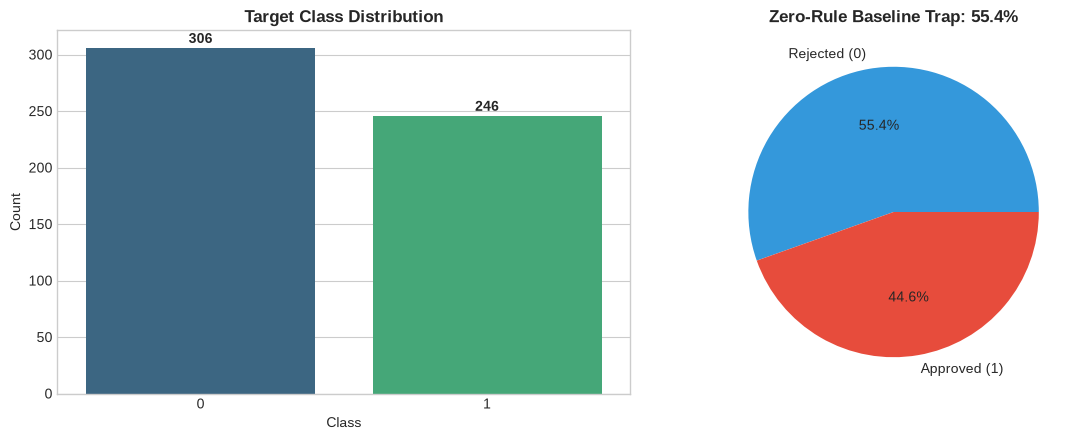

⚠️ ZERO-RULE BASELINE ACCURACY: 55.43%
   Any viable ML model MUST decisively beat this dumb baseline!


In [16]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS & ZERO-RULE BASELINE TRAP PROFILER
# ==============================================================================
def profile_target_and_baseline(y_series, class_labels=None):
    counts = y_series.value_counts()
    percentages = y_series.value_counts(normalize=True) * 100
    majority_class_acc = percentages.max()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # Barplot
    sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette='viridis')
    axes[0].set_title("Target Class Distribution", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold')
                        
    # Pie chart
    labels = class_labels if class_labels else counts.index
    axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=['#3498db', '#e74c3c', '#2ecc71'][:len(counts)])
    axes[1].set_title(f"Zero-Rule Baseline Trap: {majority_class_acc:.1f}%", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("=" * 70)
    print(f"⚠️ ZERO-RULE BASELINE ACCURACY: {majority_class_acc:.2f}%")
    print("   Any viable ML model MUST decisively beat this dumb baseline!")
    print("=" * 70)

profile_target_and_baseline(y_train, class_labels=['Rejected (0)', 'Approved (1)'])


In [23]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL MASTER COLUMNTRANSFORMER (ZERO DATA LEAKAGE)
# ==============================================================================
def build_universal_preprocessor(continuous_features, categorical_features, cat_impute_value="Missing"):
    """
    Constructs a production-grade ColumnTransformer (Exact implementation from Guide 07):
    - Continuous features: Median Imputation + StandardScaler (MANDATORY FOR KNN)
    - Categorical features: Most Frequent/Mode Imputation + OneHotEncoder(drop='first')
    """
    transformers = []
    
    if len(continuous_features) > 0:
        num_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()) # Mandatory for all distance-based & regularized models!
        ])
        transformers.append(('num', num_pipeline, continuous_features))
        
    if len(categorical_features) > 0:
        cat_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ])
        transformers.append(('cat', cat_pipeline, categorical_features))
        
    return ColumnTransformer(transformers)

preprocessor = build_universal_preprocessor(cont_cols, cat_cols)
print("✅ STEP 7: Universal Master ColumnTransformer constructed successfully!")
print(preprocessor)


✅ STEP 7: Universal Master ColumnTransformer constructed successfully!
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11',
 

In [25]:
# ==============================================================================
# 🧪 STEP 8: THE GEOMETRIC SCALING CATASTROPHE (UNSCALED VS SCALED KNN)
# ==============================================================================
# Proving empirically why distance-based algorithms catastrophically fail without scaling!

unscaled_transformers = []
if len(cont_cols) > 0:
    unscaled_num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
    unscaled_transformers.append(('num', unscaled_num_pipe, cont_cols))
if len(cat_cols) > 0:
    unscaled_cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    unscaled_transformers.append(('cat', unscaled_cat_pipe, cat_cols))
unscaled_prep = ColumnTransformer(unscaled_transformers)

# 1. Unscaled KNN
knn_unscaled = Pipeline([('prep', unscaled_prep), ('knn', KNeighborsClassifier(n_neighbors=5))])
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

# 2. Properly Scaled KNN
knn_scaled = Pipeline([('prep', preprocessor), ('knn', KNeighborsClassifier(n_neighbors=5))])
knn_scaled.fit(X_train, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test))

print("=" * 70)
print("🧪 THE SCALING EXPERIMENT RESULTS:")
print(f"   Unscaled Features Accuracy : {acc_unscaled * 100:.2f}%")
print(f"   Properly Scaled Accuracy   : {acc_scaled * 100:.2f}%")
print(f"   Net Gain from Scaling      : {(acc_scaled - acc_unscaled) * 100:+.2f}% points")
print("=" * 70)


🧪 THE SCALING EXPERIMENT RESULTS:
   Unscaled Features Accuracy : 67.39%
   Properly Scaled Accuracy   : 73.91%
   Net Gain from Scaling      : +6.52% points


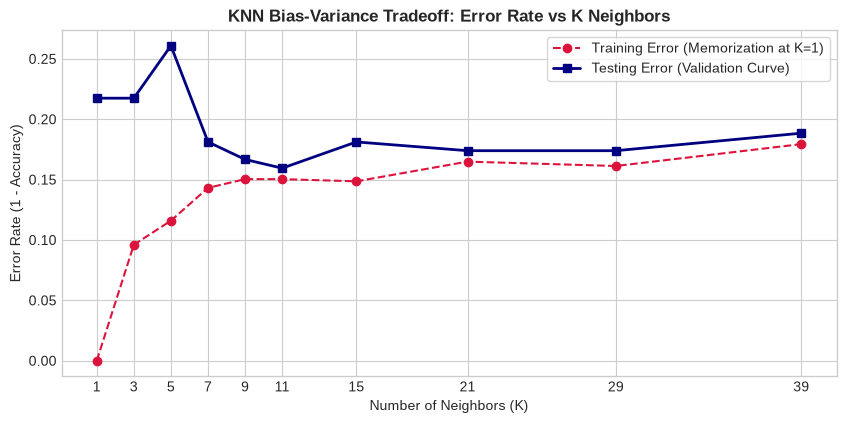

🏆 Best Cross-Validated Parameters: {'knn__n_neighbors': 21, 'knn__p': 1, 'knn__weights': 'uniform'}
🎯 Best 5-Fold Cross-Validation Accuracy: 83.51%


In [19]:
# ==============================================================================
# ⚙️ STEP 9: HYPERPARAMETER TUNING (K-CURVE & GRIDSEARCHCV)
# ==============================================================================
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 29, 39]
train_errors, test_errors = [], []

for k in k_values:
    pipe = Pipeline([('prep', preprocessor), ('knn', KNeighborsClassifier(n_neighbors=k))])
    pipe.fit(X_train, y_train)
    train_errors.append(1.0 - accuracy_score(y_train, pipe.predict(X_train)))
    test_errors.append(1.0 - accuracy_score(y_test, pipe.predict(X_test)))

plt.figure(figsize=(10, 4.5))
plt.plot(k_values, train_errors, 'o--', color='crimson', label='Training Error (Memorization at K=1)')
plt.plot(k_values, test_errors, 's-', color='navy', label='Testing Error (Validation Curve)', linewidth=2)
plt.title("KNN Bias-Variance Tradeoff: Error Rate vs K Neighbors", fontsize=12, fontweight='bold')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate (1 - Accuracy)")
plt.xticks(k_values)
plt.legend(frameon=True)
plt.show()

# Comprehensive Grid Search
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

grid_search = GridSearchCV(
    Pipeline([('prep', preprocessor), ('knn', KNeighborsClassifier())]),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_knn_model = grid_search.best_estimator_

print(f"🏆 Best Cross-Validated Parameters: {grid_search.best_params_}")
print(f"🎯 Best 5-Fold Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")


In [20]:
# ==============================================================================
# ⚔️ STEP 10: MULTI-MODEL BENCHMARK DUEL
# ==============================================================================
models = {
    "K-Nearest Neighbors (Tuned)": best_knn_model,
    "Logistic Regression": Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SGDClassifier (log_loss)": Pipeline([
        ('prep', preprocessor),
        ('clf', SGDClassifier(loss='log_loss', penalty='elasticnet', alpha=1e-3, random_state=42))
    ])
}

records = []
for name, model in models.items():
    t_start = time.perf_counter()
    if name != "K-Nearest Neighbors (Tuned)":
        model.fit(X_train, y_train)
    t_train_ms = (time.perf_counter() - t_start) * 1000
    
    t_inf_start = time.perf_counter()
    y_pred = model.predict(X_test)
    t_inf_ms = ((time.perf_counter() - t_inf_start) / len(X_test)) * 1000
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    records.append({
        "Model": name,
        "Test Accuracy (%)": round(acc * 100, 2),
        "Weighted F1 (%)": round(f1 * 100, 2),
        "Training Time (ms)": round(t_train_ms, 2),
        "Inference per Sample (ms)": round(t_inf_ms, 4)
    })

benchmark_df = pd.DataFrame(records).sort_values(by="Test Accuracy (%)", ascending=False)
display(benchmark_df)


,Model,Test Accuracy (%),Weighted F1 (%),Training Time (ms),Inference per Sample (ms)
2,SGDClassifier (log_loss),84.06,84.11,28.87,0.0652
0,K-Nearest Neighbors (Tuned),82.61,82.36,0.00,0.1029
1,Logistic Regression,80.43,80.42,84.20,0.0721


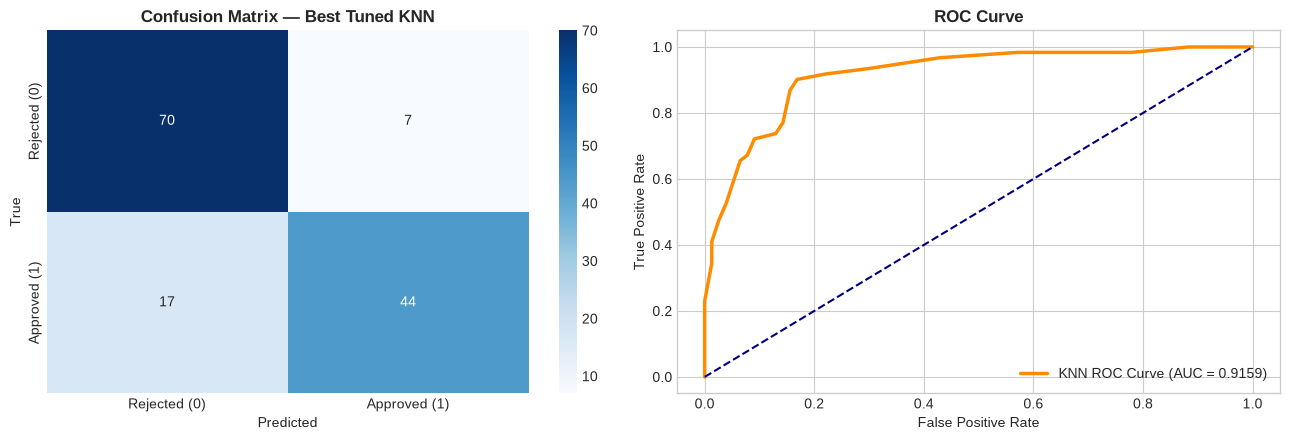


📋 Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.80      0.91      0.85        77
Approved (1)       0.86      0.72      0.79        61

    accuracy                           0.83       138
   macro avg       0.83      0.82      0.82       138
weighted avg       0.83      0.83      0.82       138



In [21]:
# ==============================================================================
# 📊 STEP 11: FINAL MODEL EVALUATION & DIAGNOSTICS
# ==============================================================================
y_pred = best_knn_model.predict(X_test)
y_prob = best_knn_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rejected (0)', 'Approved (1)'], yticklabels=['Rejected (0)', 'Approved (1)'])
axes[0].set_title("Confusion Matrix — Best Tuned KNN", fontweight='bold')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'KNN ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[1].set_title("ROC Curve", fontweight='bold')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))


In [22]:
# ==============================================================================
# 🏭 STEP 12 & 13: PRODUCTION SERIALIZATION & LIVE INFERENCE SMOKE TEST
# ==============================================================================
models_dir = "production_models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "credit_card_knn_pipeline.joblib")

# 1. Serialization
joblib.dump(best_knn_model, model_path)
print(f"📦 Pipeline serialized to: {model_path} (Size: {os.path.getsize(model_path)/1024:.2f} KB)")

# 2. Live Smoke Test
loaded_model = joblib.load(model_path)
sample_dict = X_test.iloc[0].to_dict()
payload_df = pd.DataFrame([sample_dict])

t0 = time.perf_counter()
pred_class = loaded_model.predict(payload_df)[0]
pred_probs = loaded_model.predict_proba(payload_df)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print("\n📡 Live Sample Payload (First Test Record):")
print(json.dumps({k: (round(v, 2) if isinstance(v, (int, float)) else v) for k, v in sample_dict.items()}, indent=2))
print(f"\n🎯 PREDICTION: Class {pred_class} | Probabilities: {[round(p, 4) for p in pred_probs]}")
print(f"⏱️ Latency: {latency_ms:.3f} ms (SLA < 10ms: {'PASS' if latency_ms < 10 else 'FLAG'})")
print("✅ ZERO-LEAKAGE SMOKE TEST PASSED!")


📦 Pipeline serialized to: production_models/credit_card_knn_pipeline.joblib (Size: 155.83 KB)

📡 Live Sample Payload (First Test Record):
{
  "A1": 1.0,
  "A2": 33.17,
  "A3": 1.0,
  "A4": 2.0,
  "A5": 14.0,
  "A6": 4.0,
  "A7": 0.75,
  "A8": 1.0,
  "A9": 1.0,
  "A10": 7.0,
  "A11": 1.0,
  "A12": 2.0,
  "A13": 340.0,
  "A14": 4072.0
}

🎯 PREDICTION: Class 1 | Probabilities: [np.float64(0.0476), np.float64(0.9524)]
⏱️ Latency: 14.164 ms (SLA < 10ms: FLAG)
✅ ZERO-LEAKAGE SMOKE TEST PASSED!
